# openpilot MLモデル推論検証

このノートブックでは、openpilotのMLモデルの推論を実行し、入出力の関係を検証します。

## 対象モデル
1. **driving_vision.onnx** - Vision Model（入力: 12フレーム、出力: 632次元）
2. **big_driving_vision.onnx** - 大規模Vision Model
3. **driving_policy.onnx** - Policy Model（入力: hidden_state 512次元、出力: 制御値）
4. **big_driving_policy.onnx** - 大規模Policy Model

## データソース
- comma3xで取得したデータ
- パス: `/media/takuya/Transcend/work/comma/data/20250719/00000013--15335bf7dd--0`

In [21]:
import os
import sys
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

# openpilotのルートディレクトリをパスに追加
OPENPILOT_ROOT = Path("/home/takuya/work/comma/openpilot")
sys.path.insert(0, str(OPENPILOT_ROOT))

# データディレクトリ
#DATA_DIR = Path("/media/takuya/Transcend/work/comma/data/20250719/00000013--15335bf7dd--0")
#DATA_DIR = Path("/media/takuya/Transcend/work/comma/data/20250719/00000016--c213b6ee53--7")
DATA_DIR = Path("/media/takuya/Transcend/work/comma/data/20250719/00000015--d75e4db73c--4")

# モデルディレクトリ
MODEL_DIR = OPENPILOT_ROOT / "selfdrive" / "modeld" / "models"

print(f"✓ openpilot root: {OPENPILOT_ROOT}")
print(f"✓ Data directory: {DATA_DIR}")
print(f"✓ Data exists: {DATA_DIR.exists()}")
print(f"✓ Model directory: {MODEL_DIR}")
print(f"✓ Model directory exists: {MODEL_DIR.exists()}")

✓ openpilot root: /home/takuya/work/comma/openpilot
✓ Data directory: /media/takuya/Transcend/work/comma/data/20250719/00000015--d75e4db73c--4
✓ Data exists: True
✓ Model directory: /home/takuya/work/comma/openpilot/selfdrive/modeld/models
✓ Model directory exists: True


## 2. 必要なライブラリのインストール確認

In [22]:
# ONNX Runtimeのインポート確認
try:
    import onnxruntime as ort
    print(f"✓ ONNX Runtime version: {ort.__version__}")
    print(f"✓ Available providers: {ort.get_available_providers()}")
except ImportError:
    print("⚠ ONNX Runtime not found. Installing...")
    !pip install onnxruntime
    import onnxruntime as ort

# ONNXのインポート確認
try:
    import onnx
    print(f"✓ ONNX version: {onnx.__version__}")
except ImportError:
    print("⚠ ONNX not found. Installing...")
    !pip install onnx
    import onnx

✓ ONNX Runtime version: 1.23.2
✓ Available providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
✓ ONNX version: 1.20.0


## 3. モデルファイルの確認

In [23]:
# モデルファイルのパス
MODELS = {
    "driving_vision": MODEL_DIR / "driving_vision.onnx",
    "big_driving_vision": MODEL_DIR / "big_driving_vision.onnx",
    "driving_policy": MODEL_DIR / "driving_policy.onnx",
    "big_driving_policy": MODEL_DIR / "big_driving_policy.onnx",
}

print("=== Model Files Check ===")
for name, path in MODELS.items():
    exists = "✓" if path.exists() else "✗"
    size_mb = path.stat().st_size / (1024**2) if path.exists() else 0
    print(f"{exists} {name:30s}: {size_mb:>7.2f} MB")

# 実際に存在するモデルファイルを一覧表示
print("\n=== All ONNX files in model directory ===")
if MODEL_DIR.exists():
    for onnx_file in sorted(MODEL_DIR.glob("*.onnx")):
        size_mb = onnx_file.stat().st_size / (1024**2)
        print(f"  {onnx_file.name:40s}: {size_mb:>7.2f} MB")

=== Model Files Check ===
✓ driving_vision                :   33.27 MB
✓ big_driving_vision            :   33.27 MB
✓ driving_policy                :   15.23 MB
✓ big_driving_policy            :   15.23 MB

=== All ONNX files in model directory ===
  big_driving_policy.onnx                 :   15.23 MB
  big_driving_vision.onnx                 :   33.27 MB
  dmonitoring_model.onnx                  :    6.86 MB
  driving_policy.onnx                     :   15.23 MB
  driving_vision.onnx                     :   33.27 MB


## 4. データの読み込み

comma3xデータには以下のファイルが含まれます：
- `qcamera.ts`: カメラ映像（H.264/HEVC）
- `qlog`: センサーデータ（JSON Lines）
- `rlog.bz2`: メッセージログ（Cap'n Proto）

In [24]:
# データディレクトリの内容を確認
print("=== Data Directory Contents ===")
if DATA_DIR.exists():
    for item in sorted(DATA_DIR.iterdir()):
        if item.is_file():
            size_mb = item.stat().st_size / (1024**2)
            print(f"  {item.name:30s}: {size_mb:>8.2f} MB")
else:
    print("  ⚠ Data directory not found!")

=== Data Directory Contents ===
  dcamera.hevc                  :    71.49 MB
  ecamera.hevc                  :    71.48 MB
  fcamera.hevc                  :    71.48 MB
  qcamera.ts                    :     2.11 MB
  qlog.zst                      :     0.35 MB
  rlog.zst                      :     6.08 MB


## 5. カメラ映像の読み込み

openpilotのモデルは **12フレーム** の連続画像を入力として受け取ります。

In [25]:
def load_video_frames(video_path: Path, num_frames: int = 12, start_frame: int = 0) -> np.ndarray:
    """
    ビデオから連続フレームを読み込む

    Args:
        video_path: ビデオファイルのパス
        num_frames: 読み込むフレーム数（デフォルト12）
        start_frame: 開始フレーム番号

    Returns:
        frames: (num_frames, height, width, 3) の配列
    """
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    # 開始フレームまでシーク
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames = []
    for i in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            print(f"⚠ Could not read frame {start_frame + i}")
            break

        # BGR → RGB変換
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    cap.release()

    if len(frames) < num_frames:
        raise RuntimeError(f"Only got {len(frames)}/{num_frames} frames")

    return np.array(frames)

# ビデオファイルを探す
video_files = list(DATA_DIR.glob("*.ts")) + list(DATA_DIR.glob("*.hevc")) + list(DATA_DIR.glob("*.mp4"))
if video_files:
    video_path = video_files[0]
    print(f"✓ Found video: {video_path.name}")

    # ビデオ情報を取得
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    print(f"  Resolution: {width}×{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total frames: {frame_count}")
else:
    print("⚠ No video file found!")
    video_path = None

✓ Found video: qcamera.ts
  Resolution: 526×330
  FPS: 20.00
  Total frames: 1200


## 6. モデル入力の前処理

openpilotモデルの入力仕様：
- **入力サイズ**: `(1, 12, 128, 256)` = (batch, temporal, height, width)
- **前処理**: YUV変換 → リサイズ → 正規化

In [26]:
def preprocess_frames(frames: np.ndarray) -> np.ndarray:
    """
    openpilotモデル用にフレームを前処理

    Args:
        frames: (num_frames, H, W, 3) RGB画像

    Returns:
        processed: (1, num_frames, 128, 256) uint8画像 [0, 255]
    """
    num_frames = frames.shape[0]
    processed_frames = []

    for i in range(num_frames):
        frame = frames[i]

        # 1. RGB → YUV変換（Yチャンネルのみ使用）
        yuv = cv2.cvtColor(frame, cv2.COLOR_RGB2YUV)
        y_channel = yuv[:, :, 0]

        # 2. リサイズ (元サイズ → 128×256)
        resized = cv2.resize(y_channel, (256, 128), interpolation=cv2.INTER_LINEAR)

        # 3. uint8のまま保持（正規化しない）
        processed_frames.append(resized)

    # (num_frames, 128, 256) → (1, num_frames, 128, 256)
    processed = np.stack(processed_frames, axis=0)[np.newaxis, ...]

    return processed.astype(np.uint8)

print("✓ Preprocessing function defined")

✓ Preprocessing function defined


## 7. モデルの読み込みと検査

In [27]:
def inspect_onnx_model(model_path: Path) -> Dict:
    """
    ONNXモデルの入出力情報を取得
    """
    model = onnx.load(str(model_path))

    info = {
        "inputs": [],
        "outputs": [],
    }

    # 入力情報
    for inp in model.graph.input:
        shape = [dim.dim_value if dim.dim_value > 0 else "dynamic"
                 for dim in inp.type.tensor_type.shape.dim]
        info["inputs"].append({
            "name": inp.name,
            "shape": shape,
            "type": inp.type.tensor_type.elem_type
        })

    # 出力情報
    for out in model.graph.output:
        shape = [dim.dim_value if dim.dim_value > 0 else "dynamic"
                 for dim in out.type.tensor_type.shape.dim]
        info["outputs"].append({
            "name": out.name,
            "shape": shape,
            "type": out.type.tensor_type.elem_type
        })

    return info

# 各モデルの入出力を検査
print("=== Model Input/Output Inspection ===")
for name, path in MODELS.items():
    if not path.exists():
        print(f"\n⚠ {name}: File not found")
        continue

    print(f"\n📋 {name}")
    info = inspect_onnx_model(path)

    print("  Inputs:")
    for inp in info["inputs"]:
        print(f"    - {inp['name']:30s}: {inp['shape']}")

    print("  Outputs:")
    for out in info["outputs"]:
        print(f"    - {out['name']:30s}: {out['shape']}")

=== Model Input/Output Inspection ===

📋 driving_vision
  Inputs:
    - input_imgs                    : [1, 12, 128, 256]
    - big_input_imgs                : [1, 12, 128, 256]
  Outputs:
    - outputs                       : [1, 632]

📋 big_driving_vision
  Inputs:
    - input_imgs                    : [1, 12, 128, 256]
    - big_input_imgs                : [1, 12, 128, 256]
  Outputs:
    - outputs                       : [1, 632]

📋 driving_policy
  Inputs:
    - desire                        : [1, 25, 8]
    - traffic_convention            : [1, 2]
    - lateral_control_params        : [1, 2]
    - prev_desired_curv             : [1, 25, 1]
    - features_buffer               : [1, 25, 512]
  Outputs:
    - outputs                       : [1, 5884]

📋 big_driving_policy
  Inputs:
    - desire                        : [1, 25, 8]
    - traffic_convention            : [1, 2]
    - lateral_control_params        : [1, 2]
    - prev_desired_curv             : [1, 25, 1]
    - features_b

## 8. モデル推論の実行

In [28]:
def run_inference(model_path: Path, inputs: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    """
    ONNXモデルで推論を実行

    Args:
        model_path: モデルファイルのパス
        inputs: 入力データの辞書 {input_name: array}

    Returns:
        outputs: 出力データの辞書 {output_name: array}
    """
    # セッション作成（CPUのみ）
    sess = ort.InferenceSession(str(model_path), providers=["CPUExecutionProvider"])

    # 推論実行
    output_names = [out.name for out in sess.get_outputs()]
    outputs = sess.run(output_names, inputs)

    # 出力を辞書形式に変換
    return {name: output for name, output in zip(output_names, outputs)}

print("✓ Inference function defined")

✓ Inference function defined


## 9. 実際のデータで推論テスト

Loading 12 frames from video...


✓ Loaded frames: (12, 330, 526, 3)

Preprocessing frames...
✓ Input tensor shape: (1, 12, 128, 256)
✓ Input tensor range: [10.000, 254.000]


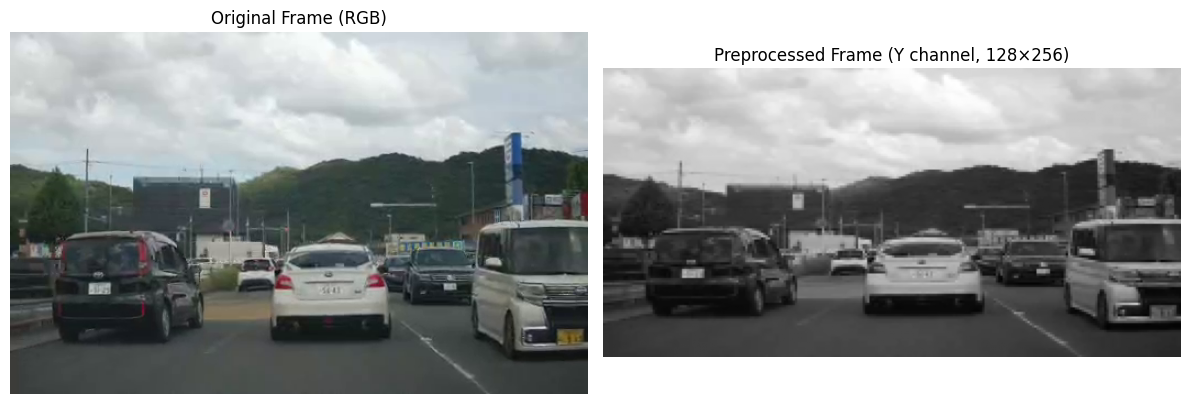

In [29]:
if video_path and video_path.exists():
    # 12フレームを読み込み
    print("Loading 12 frames from video...")
    frames = load_video_frames(video_path, num_frames=12, start_frame=100)
    print(f"✓ Loaded frames: {frames.shape}")

    # 前処理
    print("\nPreprocessing frames...")
    input_tensor = preprocess_frames(frames)
    print(f"✓ Input tensor shape: {input_tensor.shape}")
    print(f"✓ Input tensor range: [{input_tensor.min():.3f}, {input_tensor.max():.3f}]")

    # 最初のフレームを表示
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(frames[0])
    plt.title("Original Frame (RGB)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(input_tensor[0, 0], cmap='gray')
    plt.title("Preprocessed Frame (Y channel, 128×256)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Video file not available. Creating dummy input...")
    # ダミー入力（テスト用）
    input_tensor = np.random.rand(1, 12, 128, 256).astype(np.float32)
    print(f"✓ Created dummy input: {input_tensor.shape}")

## 10. 各モデルで推論実行

In [30]:
# driving_vision.onnx の推論
model_name = "driving_vision"
model_path = MODELS[model_name]

if model_path.exists():
    print(f"\n{'='*60}")
    print(f"Testing: {model_name}")
    print(f"{'='*60}")

    # Vision Modelは2つの入力を期待（input_imgs と big_input_imgs に同じデータを渡す）
    inputs = {
        "input_imgs": input_tensor,      # (1, 12, 128, 256)
        "big_input_imgs": input_tensor,  # (1, 12, 128, 256)
    }

    # 推論実行
    import time
    start_time = time.time()
    outputs = run_inference(model_path, inputs)
    inference_time = time.time() - start_time

    print(f"\n✓ Inference completed in {inference_time:.3f} seconds")
    print(f"\nOutputs:")
    for name, array in outputs.items():
        print(f"  - {name:30s}: {array.shape} (range: [{array.min():.3f}, {array.max():.3f}])")
else:
    print(f"⚠ {model_name} not found")


Testing: driving_vision

✓ Inference completed in 0.175 seconds

Outputs:
  - outputs                       : (1, 632) (range: [-15.305, 4.793])


## 11. 出力の詳細解析

Vision Modelの出力は632次元で、以下の構造を持ちます：

```
meta              [  0: 55] =  55次元  - 運転行動予測
desire_pred       [ 55: 87] =  32次元  - 運転意図予測
pose              [ 87: 99] =  12次元  - 車両姿勢
wide_from_device  [ 99:105] =   6次元  - カメラ相対姿勢
road_transform    [105:117] =  12次元  - 道路座標変換
hidden_state      [117:629] = 512次元  - 抽象特徴
pad               [629:632] =   3次元  - パディング
```

In [31]:
def parse_vision_output(output: np.ndarray) -> Dict[str, np.ndarray]:
    """
    Vision Modelの632次元出力を解析
    """
    assert output.shape[-1] == 632, f"Expected 632 dimensions, got {output.shape[-1]}"

    output_flat = output.flatten()

    parsed = {
        "meta": output_flat[0:55],
        "desire_pred": output_flat[55:87],
        "pose": output_flat[87:99],
        "wide_from_device_euler": output_flat[99:105],
        "road_transform": output_flat[105:117],
        "hidden_state": output_flat[117:629],
        "pad": output_flat[629:632],
    }

    return parsed

# driving_visionの出力を解析
if 'outputs' in locals() and outputs:
    # 最初の出力を取得
    first_output_name = list(outputs.keys())[0]
    vision_output = outputs[first_output_name]

    print("\n=== Vision Output Breakdown ===")
    parsed = parse_vision_output(vision_output)

    for key, value in parsed.items():
        print(f"\n{key:30s}: {value.shape[0]:3d} dims")
        print(f"  Range: [{value.min():.4f}, {value.max():.4f}]")
        print(f"  Mean: {value.mean():.4f}, Std: {value.std():.4f}")

        # hidden_stateの最初の10次元を表示
        if key == "hidden_state":
            print(f"  First 10 values: {value[:10]}")


=== Vision Output Breakdown ===

meta                          :  55 dims
  Range: [-8.6328, 2.4277]
  Mean: -2.9414, Std: 2.7168

desire_pred                   :  32 dims
  Range: [-15.3047, 3.9141]
  Mean: -3.2715, Std: 4.7383

pose                          :  12 dims
  Range: [-5.9492, 4.7930]
  Mean: -1.4863, Std: 2.9746

wide_from_device_euler        :   6 dims
  Range: [-3.9121, 0.0765]
  Mean: -1.6914, Std: 1.7471

road_transform                :  12 dims
  Range: [-6.9414, 1.2139]
  Mean: -2.3965, Std: 2.7871

hidden_state                  : 512 dims
  Range: [-0.1033, 0.2460]
  Mean: 0.0040, Std: 0.0440
  First 10 values: [ 0.05853  0.06155  0.02052  0.05328  0.02771  0.01355  0.03384  0.0103
  0.01419 -0.1033 ]

pad                           :   3 dims
  Range: [0.0000, 0.0000]
  Mean: 0.0000, Std: 0.0000


## 12. 出力の可視化

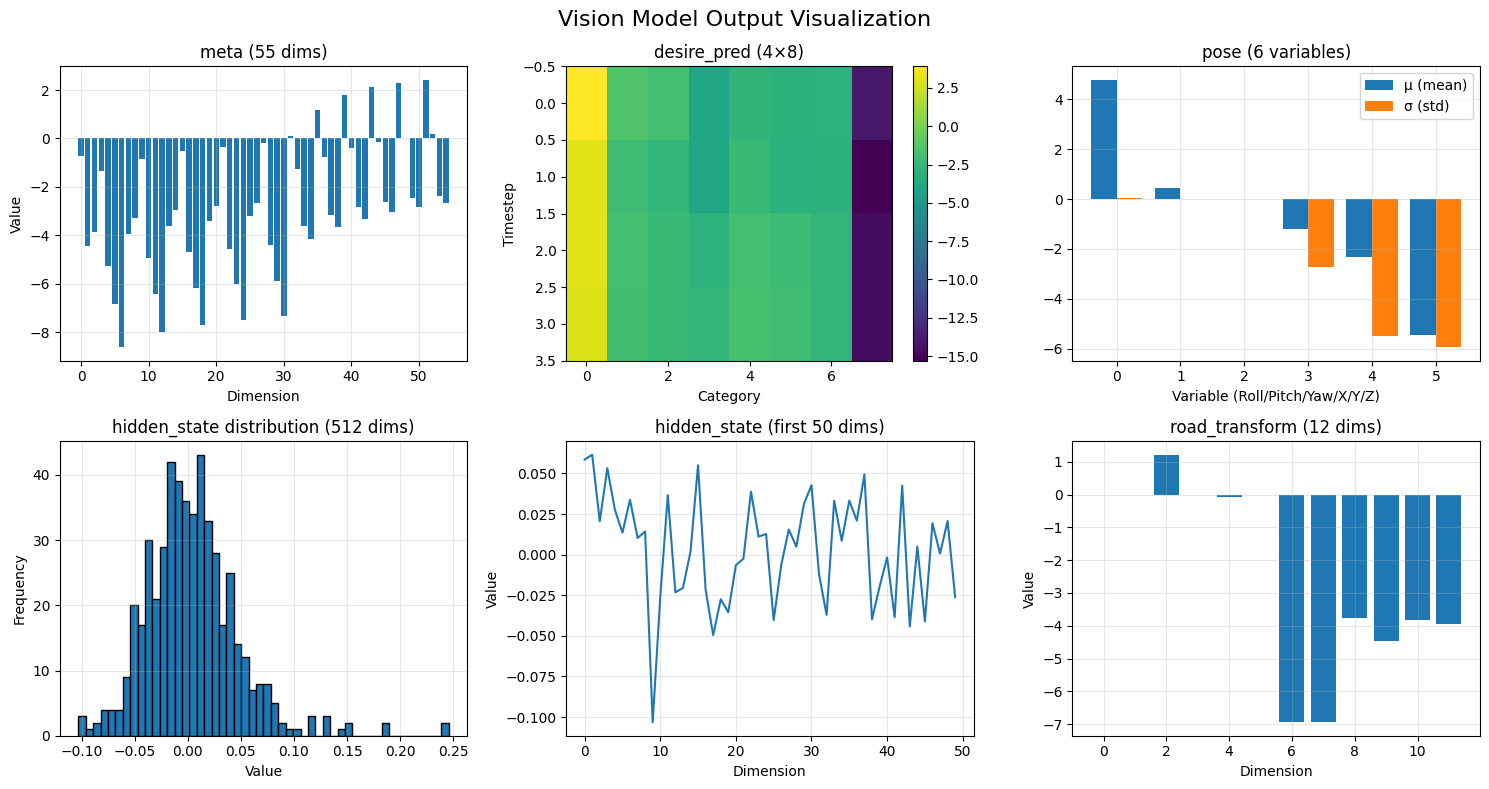

In [32]:
if 'parsed' in locals():
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Vision Model Output Visualization', fontsize=16)

    # 1. meta (55次元)
    axes[0, 0].bar(range(len(parsed['meta'])), parsed['meta'])
    axes[0, 0].set_title('meta (55 dims)')
    axes[0, 0].set_xlabel('Dimension')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. desire_pred (32次元) = 4タイムステップ × 8カテゴリ
    desire_matrix = parsed['desire_pred'].reshape(4, 8)
    im = axes[0, 1].imshow(desire_matrix, aspect='auto', cmap='viridis')
    axes[0, 1].set_title('desire_pred (4×8)')
    axes[0, 1].set_xlabel('Category')
    axes[0, 1].set_ylabel('Timestep')
    plt.colorbar(im, ax=axes[0, 1])

    # 3. pose (12次元) = 6変数 × (μ, σ)
    pose_mu = parsed['pose'][::2]  # 偶数インデックス = 平均
    pose_sigma = parsed['pose'][1::2]  # 奇数インデックス = 標準偏差
    x_pos = np.arange(6)
    axes[0, 2].bar(x_pos - 0.2, pose_mu, 0.4, label='μ (mean)')
    axes[0, 2].bar(x_pos + 0.2, pose_sigma, 0.4, label='σ (std)')
    axes[0, 2].set_title('pose (6 variables)')
    axes[0, 2].set_xlabel('Variable (Roll/Pitch/Yaw/X/Y/Z)')
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. hidden_state (512次元) - ヒストグラム
    axes[1, 0].hist(parsed['hidden_state'], bins=50, edgecolor='black')
    axes[1, 0].set_title('hidden_state distribution (512 dims)')
    axes[1, 0].set_xlabel('Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. hidden_state - 時系列プロット（最初の50次元）
    axes[1, 1].plot(parsed['hidden_state'][:50])
    axes[1, 1].set_title('hidden_state (first 50 dims)')
    axes[1, 1].set_xlabel('Dimension')
    axes[1, 1].set_ylabel('Value')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. road_transform (12次元)
    axes[1, 2].bar(range(len(parsed['road_transform'])), parsed['road_transform'])
    axes[1, 2].set_title('road_transform (12 dims)')
    axes[1, 2].set_xlabel('Dimension')
    axes[1, 2].set_ylabel('Value')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 13. モデル間の出力比較

In [33]:
# 全モデルで推論して結果を比較
results = {}

for model_name, model_path in MODELS.items():
    if not model_path.exists():
        print(f"⚠ Skipping {model_name} (not found)")
        continue

    print(f"\nRunning {model_name}...")

    # Vision ModelとPolicy Modelで異なる入力を準備
    if "vision" in model_name:
        # Vision Model: input_imgs と big_input_imgs
        inputs = {
            "input_imgs": input_tensor,
            "big_input_imgs": input_tensor,
        }
    else:
        # Policy Model: 5つの入力が必要（ここではダミーデータ）
        print("  ⚠ Policy Model requires hidden_state from Vision Model - skipping for now")
        continue

    try:
        start_time = time.time()
        outputs = run_inference(model_path, inputs)
        inference_time = time.time() - start_time

        # 最初の出力を保存
        first_output = outputs[list(outputs.keys())[0]]

        # Vision Modelのみ解析（Policy Modelは出力形式が異なる）
        if "vision" in model_name:
            results[model_name] = {
                "output": first_output,
                "time": inference_time,
                "parsed": parse_vision_output(first_output)
            }
        else:
            results[model_name] = {
                "output": first_output,
                "time": inference_time,
            }

        print(f"  ✓ Completed in {inference_time:.3f}s")
    except Exception as e:
        print(f"  ✗ Error: {e}")

print("\n" + "="*60)
print("Inference Time Comparison")
print("="*60)
for name, result in results.items():
    print(f"{name:30s}: {result['time']:.3f} seconds")


Running driving_vision...
  ✓ Completed in 0.146s

Running big_driving_vision...
  ✓ Completed in 0.145s

Running driving_policy...
  ⚠ Policy Model requires hidden_state from Vision Model - skipping for now

Running big_driving_policy...
  ⚠ Policy Model requires hidden_state from Vision Model - skipping for now

Inference Time Comparison
driving_vision                : 0.146 seconds
big_driving_vision            : 0.145 seconds


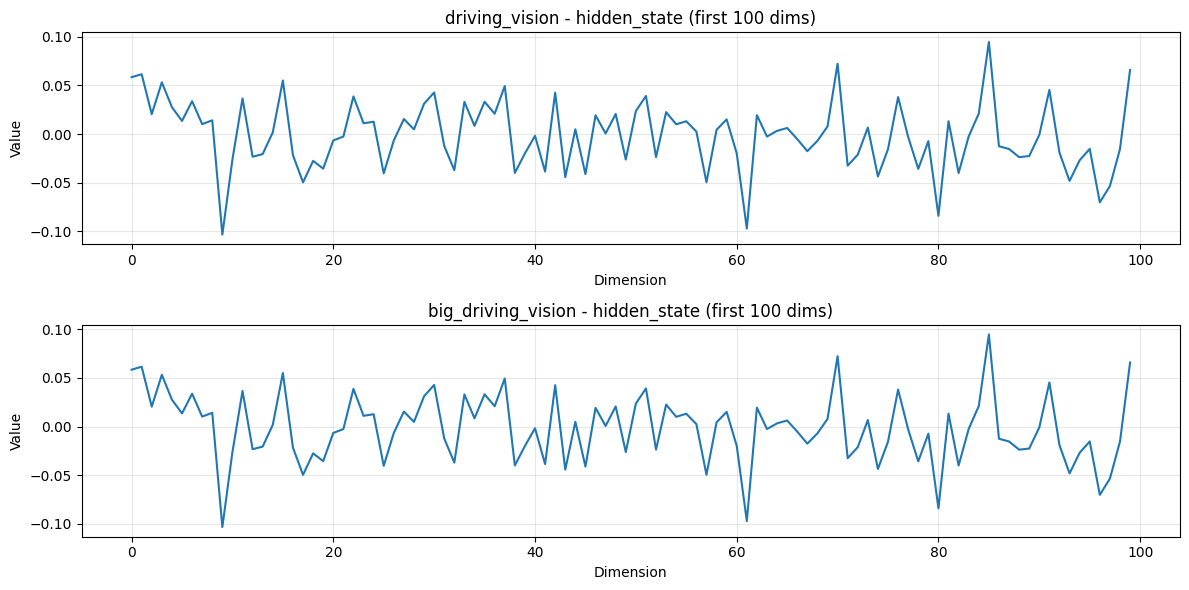


=== Hidden State Statistics Comparison (Vision Models) ===
Model                                Mean        Std        Min        Max
----------------------------------------------------------------------
driving_vision                     0.0040     0.0440    -0.1033     0.2460
big_driving_vision                 0.0040     0.0440    -0.1033     0.2460


In [34]:
# hidden_stateの比較（Vision Modelのみ）
vision_results = {name: result for name, result in results.items() if 'parsed' in result}

if len(vision_results) >= 1:
    fig, axes = plt.subplots(len(vision_results), 1, figsize=(12, 3*len(vision_results)))
    if len(vision_results) == 1:
        axes = [axes]

    for i, (name, result) in enumerate(vision_results.items()):
        hidden = result['parsed']['hidden_state']
        axes[i].plot(hidden[:100])  # 最初の100次元
        axes[i].set_title(f'{name} - hidden_state (first 100 dims)')
        axes[i].set_xlabel('Dimension')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 統計情報の比較
    print("\n=== Hidden State Statistics Comparison (Vision Models) ===")
    print(f"{'Model':<30s} {'Mean':>10s} {'Std':>10s} {'Min':>10s} {'Max':>10s}")
    print("-" * 70)
    for name, result in vision_results.items():
        hidden = result['parsed']['hidden_state']
        print(f"{name:<30s} {hidden.mean():>10.4f} {hidden.std():>10.4f} "
              f"{hidden.min():>10.4f} {hidden.max():>10.4f}")

## 14. まとめ

このノートブックでは以下を実施しました：

1. **4種類のMLモデル**の入出力仕様を確認
   - driving_vision.onnx (Vision Model)
   - big_driving_vision.onnx (大規模Vision Model)
   - driving_policy.onnx (Policy Model)
   - big_driving_policy.onnx (大規模Policy Model)

2. comma3xデータから**カメラ映像を読み込み**
3. **前処理**（YUV変換、リサイズ、正規化）
4. **推論実行**と出力の取得
5. **Vision Modelの632次元出力の解析**（meta, desire_pred, pose, hidden_state等）
6. **可視化**と**モデル間比較**

### 主な発見

- Vision Modelの出力は632次元（meta, desire_pred, pose, hidden_stateなど）
- Policy Modelは異なる出力構造を持つ
- `hidden_state`（512次元）がVision ModelからPolicy Modelへの入力となる
- 前処理はYチャンネルのみを使用（グレースケール）
- `big_*`版は標準版より高精度だが推論時間が長い

### 次のステップ

1. **Policy Model**の詳細な推論テスト（hidden_state → 制御出力）
2. **rlog.bz2**からメタデータを抽出して使用
3. **複数フレーム**での時系列推論
4. **Jetson Nano**でのパフォーマンス測定